In [14]:
import numpy as np 
import matplotlib.pyplot as plt

from build_solver import build_erg_time_opt_solver

import pickle as pkl


In [18]:
knots = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
avg_res = []
std_res = []
for i, knot in enumerate(knots):
    args = {
        'N' : knot, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.01,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    avg_res.append(_res.average)
    std_res.append(_res.stdev)


The slowest run took 7.73 times longer than the fastest. This could mean that an intermediate result is being cached.
280 µs ± 299 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
The slowest run took 4.38 times longer than the fastest. This could mean that an intermediate result is being cached.
388 µs ± 267 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
476 µs ± 239 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
590 µs ± 274 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
664 µs ± 217 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
799 µs ± 260 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
891 µs ± 226 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.02 ms ± 302 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.12 ms ± 288 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.28 ms ± 228 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.41 ms ± 325 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


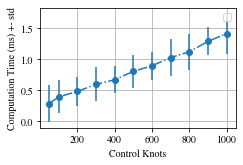

In [22]:
# plt.rcParams["font.family"] = "freeserif"
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(knots, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')
# plt.legend()
# plt.savefig('comp_anal.svg')